In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score
)

In [2]:
df = pd.read_csv('/kaggle/input/datasets/harshrishi7/123456/featured_master_dataset.csv')

In [3]:
df = df.sample(
    n=100000,
    random_state=42
)

In [4]:
df = df.sort_values('datetime')

UTILIZATION RATE PREDICTION

In [34]:
X_util = df[
    [
        'hour',
        'is_weekend',
        'volume',
        'price',
        'fast_charger_ratio',
        'occupancy_density'
    ]
]

In [35]:
y_util = df['charger_utilization_rate']

In [36]:
split = int(len(df) * 0.8)

Xu_train = X_util.iloc[:split]
Xu_test = X_util.iloc[split:]

yu_train = y_util.iloc[:split]
yu_test = y_util.iloc[split:]

In [37]:
util_model = RandomForestRegressor(
    n_estimators=30,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

util_model.fit(Xu_train, yu_train)

RandomForestRegressor(max_depth=10, n_estimators=30, n_jobs=-1, random_state=42)

In [38]:
util_pred = util_model.predict(Xu_test)

In [39]:
mae_util = mean_absolute_error(
    yu_test,
    util_pred
)

rmse_util = np.sqrt(
    mean_squared_error(
        yu_test,
        util_pred
    )
)

r2_util = r2_score(
    yu_test,
    util_pred
)

print("MAE:", mae_util)
print("RMSE:", rmse_util)
print("R²:", r2_util)

MAE: 0.0008150018869717461
RMSE: 0.0012175063029685902
R²: 0.7892417343501806


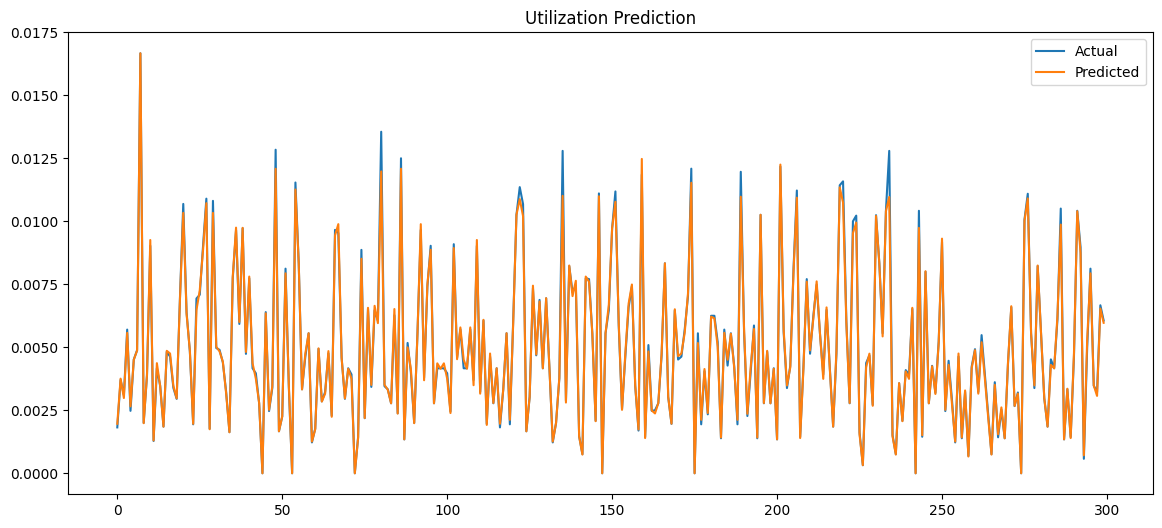

In [11]:
plt.figure(figsize=(14,6))

plt.plot(
    yu_test.values[:300],
    label='Actual'
)

plt.plot(
    util_pred[:300],
    label='Predicted'
)

plt.title('Utilization Prediction')

plt.legend()

plt.show()

EXPECTED CHARGING LOAD

In [53]:
X_load = df[
    [
        'occupancy',
        'duration',
        'charger_utilization_rate',
        'queue_length_proxy',
        'hour',
        'price',
        'is_weekend',
        'occupancy_density'
    ]
]

In [54]:
y_load = df['volume']

In [55]:
Xl_train = X_load.iloc[:split]
Xl_test = X_load.iloc[split:]

yl_train = y_load.iloc[:split]
yl_test = y_load.iloc[split:]

In [56]:
load_model = RandomForestRegressor(
    n_estimators=30,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

load_model.fit(Xl_train, yl_train)

RandomForestRegressor(max_depth=10, n_estimators=30, n_jobs=-1, random_state=42)

In [57]:
load_pred = load_model.predict(Xl_test)

In [58]:
mae_load = mean_absolute_error(
    yl_test,
    load_pred
)

rmse_load = np.sqrt(
    mean_squared_error(
        yl_test,
        load_pred
    )
)

r2_load = r2_score(
    yl_test,
    load_pred
)

print("MAE:", mae_load)
print("RMSE:", rmse_load)
print("R²:", r2_load)

MAE: 19.20408813781957
RMSE: 43.26717103076326
R²: 0.8394698834503578


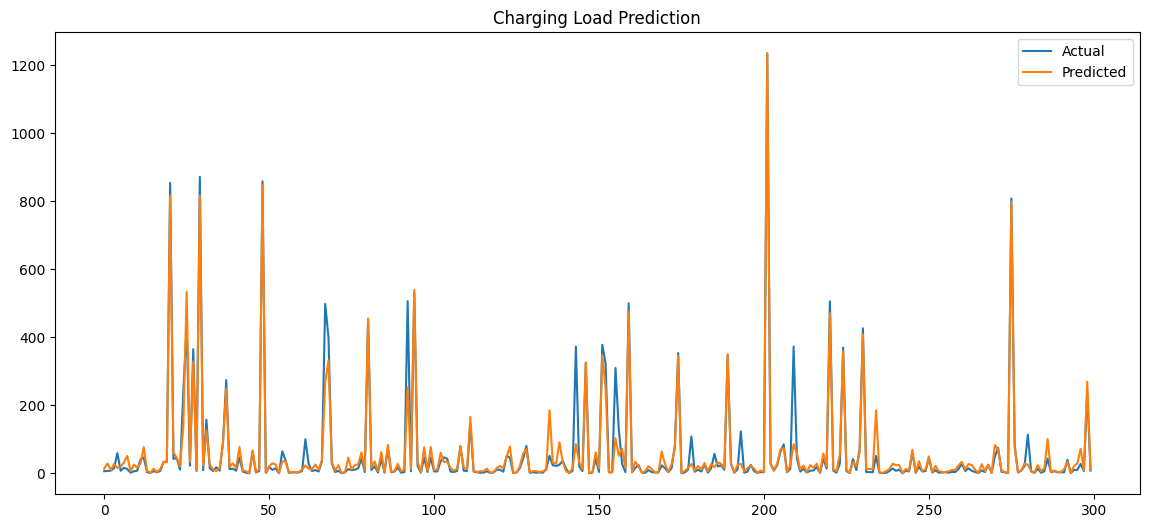

In [71]:
plt.figure(figsize=(14,6))

plt.plot(
    yl_test.values[:300],
    label='Actual'
)

plt.plot(
    load_pred[:300],
    label='Predicted'
)

plt.title('Charging Load Prediction')

plt.legend()

plt.show()

CONGESTION PROBABILITY

In [72]:
X_cong = df[
    [
        'hour',
        'is_weekend',
        'price',
        'fast_charger_ratio',
        'occupancy_density',
        'duration'
    ]
]

In [66]:
y_cong = df['high_congestion']

In [67]:
Xc_train = X_cong.iloc[:split]
Xc_test = X_cong.iloc[split:]

yc_train = y_cong.iloc[:split]
yc_test = y_cong.iloc[split:]

In [73]:
cong_model = RandomForestRegressor(
    n_estimators=30,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

cong_model.fit(Xc_train, yc_train)

RandomForestRegressor(max_depth=10, n_estimators=30, n_jobs=-1, random_state=42)

In [74]:
cong_pred = cong_model.predict(Xc_test)

In [76]:
mae_cong = mean_absolute_error(
    yc_test,
    cong_pred
)

rmse_cong = np.sqrt(
    mean_squared_error(
        yc_test,
        cong_pred
    )
)

r2_cong = r2_score(
    yc_test,
    cong_pred
)

print("MAE:", mae_cong)
print("RMSE:", rmse_cong)
print("R²:", r2_cong)

MAE: 0.0023573226083117484
RMSE: 0.035876656823141964
R²: 0.8693396780574252


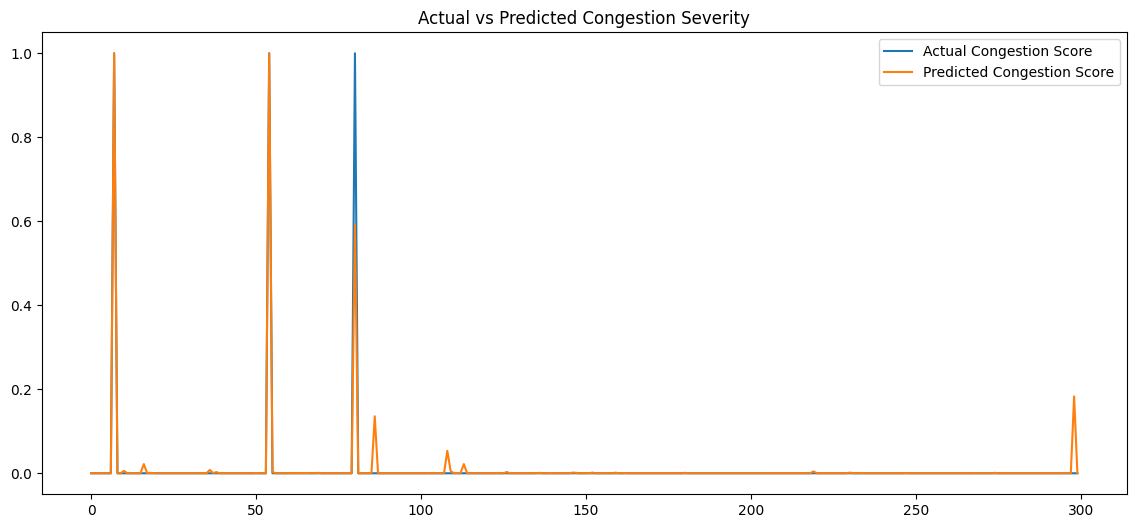

In [78]:
plt.figure(figsize=(14,6))

plt.plot(
    yc_test.values[:300],
    label='Actual Congestion Score'
)

plt.plot(
    cong_pred[:300],
    label='Predicted Congestion Score'
)

plt.title('Actual vs Predicted Congestion Severity')

plt.legend()

plt.show()

Demand Prediction Agent Developed:

1. Utilization Rate Prediction
2. Charging Load Prediction
3. Congestion Probability Prediction